# BRFSS Lifestyle Patterns vs. Disease Rates – Full Data Pipeline
**Contributors:** Yassine Yahyaoui, Bechir Ben Tekfa, Mohamed Yassine Ezzaouia

This notebook walks through the complete pipeline – from data ingestion to a clean dataset ready for an interactive Streamlit dashboard.

## Objectives
1. Download and load raw 2022 BRFSS micro‑data (SAS XPT format).
2. Select lifestyle and disease‑related variables.
3. Clean and transform the data.
4. Perform exploratory analysis & visualize key relationships.
5. Save a cleaned CSV for use in the Streamlit app.

### Setup (first‑run only)
Uncomment the next cell if you need to install required packages in a fresh environment.

In [1]:
# Optional installs – comment if already satisfied
#!pip install pandas requests nbformat seaborn matplotlib pyreadstat statsmodels


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [2]:
import pandas as pd
import requests, io, zipfile, os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Data Ingestion

In [3]:
url = "https://www.cdc.gov/brfss/annual_data/2022/files/LLCP2022XPT.zip"
zip_path = './LLCP2022.XPT.zip'
if not os.path.exists(zip_path):
    print('Downloading…')
    zipbytes = requests.get(url).content
    with open(zip_path, 'wb') as f:
        f.write(zipbytes)
else:
    print('File already downloaded.')

# Extract and load into pandas
with zipfile.ZipFile(zip_path, 'r') as zf:
    xpt_name = zf.namelist()[0]
    xpt_bytes = zf.read(xpt_name)

df_raw = pd.read_sas(io.BytesIO(xpt_bytes), format='xport')
print(f'Raw rows: {df_raw.shape[0]:,}  |  Raw columns: {df_raw.shape[1]}')

Downloading…
Raw rows: 445,132  |  Raw columns: 328


### Preview raw data

In [4]:
df_raw.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_SMOKGRP,_LCSREC,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,1.0,b'02032022',b'02',b'03',b'2022',1100.0,b'2022000001',2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,1.0,b'02042022',b'02',b'04',b'2022',1100.0,b'2022000002',2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0
2,1.0,1.0,b'02022022',b'02',b'02',b'2022',1100.0,b'2022000003',2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
3,1.0,1.0,b'02032022',b'02',b'03',b'2022',1100.0,b'2022000004',2.022000e+09,1.0,...,3.0,2.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,9.0,9.0,2.0
4,1.0,1.0,b'02022022',b'02',b'02',b'2022',1100.0,b'2022000005',2.022000e+09,1.0,...,4.0,NaN,1.0,1.000000e+01,1.0,1.400000e+02,1.0,NaN,NaN,2.0


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Columns: 328 entries, _STATE to _AIDTST4
dtypes: float64(323), object(5)
memory usage: 1.1+ GB


## 2. Data Transformation

In [6]:
# Select key lifestyle & disease variables (see codebook for details)
relevant_cols = {
    '_AGEG5YR': 'Age_Group',
    'SEXVAR' : 'Sex',
    'GENHLTH': 'General_Health',
    '_BMI5'  : 'BMI',
    'PHYSHLTH': 'Physical_Health_DaysPoor',
    'EXERANY2': 'Exercise_Last30Days',
    'DIABETE4': 'Diabetes',
    'CVDCRHD4': 'Heart_Disease'
}

df = df_raw[list(relevant_cols.keys())].rename(columns=relevant_cols)
df.head()

,Age_Group,Sex,General_Health,BMI,Physical_Health_DaysPoor,Exercise_Last30Days,Diabetes,Heart_Disease
0,13.0,2.0,2.0,NaN,88.0,2.0,1.0,2.0
1,13.0,2.0,1.0,2657.0,88.0,2.0,3.0,2.0
2,8.0,2.0,2.0,2561.0,2.0,1.0,3.0,2.0
3,14.0,2.0,1.0,2330.0,88.0,1.0,3.0,2.0
4,5.0,2.0,4.0,2177.0,2.0,1.0,3.0,2.0


### Cleaning

In [7]:
# Convert special codes to NaN (coded as 7, 9, 77, 99, etc.)
na_values = [7, 9, 77, 99]
df.replace(na_values, pd.NA, inplace=True)

# Drop rows with any NA in the selected columns
df_clean = df.dropna().copy()
print(f'Clean rows: {df_clean.shape[0]:,}  |  Columns: {df_clean.shape[1]}')

Clean rows: 306,830  |  Columns: 8


In [8]:
# Cast categorical fields
categoricals = ['Age_Group', 'Sex', 'General_Health', 'Exercise_Last30Days', 'Diabetes', 'Heart_Disease']
for col in categoricals:
    df_clean[col] = df_clean[col].astype('category')

# BMI is stored as BMI*100 → convert to true BMI
df_clean['BMI'] = df_clean['BMI'] / 100


### Save cleaned CSV

In [9]:
clean_path = './data/brfss2022_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'Saved → {clean_path}')

Saved → ./data/brfss2022_clean.csv


## 3. Exploratory Analysis & Visualization

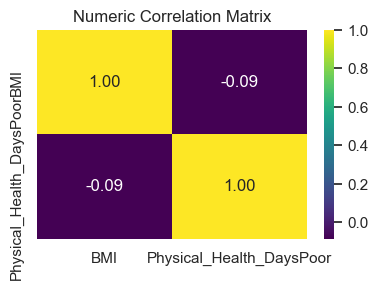

In [10]:
# Correlation matrix for numeric vars
numeric_cols = ['BMI', 'Physical_Health_DaysPoor']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Numeric Correlation Matrix')
plt.tight_layout()
plt.show()

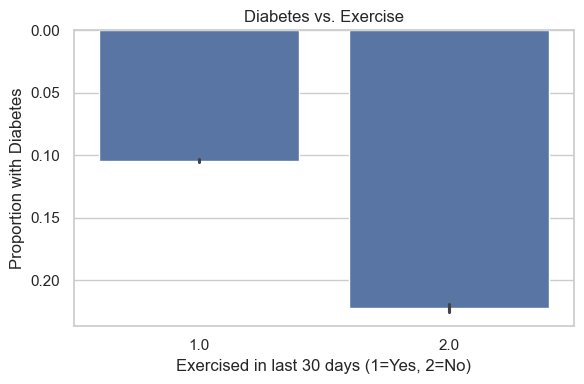

In [11]:
# Diabetes prevalence by exercise status
plt.figure(figsize=(6,4))
sns.barplot(x='Exercise_Last30Days', y='Diabetes', data=df_clean, estimator=lambda x: (x==1).mean())
plt.ylabel('Proportion with Diabetes')
plt.xlabel('Exercised in last 30 days (1=Yes, 2=No)')
plt.title('Diabetes vs. Exercise')
plt.tight_layout()
plt.show()

In [12]:
# Age buckets (already coded 1–13 for five‑year bands)
age_map = {
    1:'18–24',2:'25–29',3:'30–34',4:'35–39',5:'40–44',6:'45–49',7:'50–54',
    8:'55–59',9:'60–64',10:'65–69',11:'70–74',12:'75–79',13:'80+'}
df_clean['Age_Bucket'] = df_clean['Age_Group'].map(age_map)

# BMI categories
bins = [0,18.5,25,30,100]
labels = ['Underweight','Healthy','Overweight','Obese']
df_clean['BMI_Class'] = pd.cut(df_clean['BMI'], bins=bins, labels=labels)


In [13]:
# Pivot table: Diabetes prevalence by BMI class and Exercise status
pivot = pd.pivot_table(
    df_clean,
    values='Diabetes',
    index='BMI_Class',
    columns='Exercise_Last30Days',
    aggfunc=lambda x: (x==1).mean()
)
pivot.columns = ['Exercised','No Exercise']
pivot.style.format('{:.1%}')

C:\Users\Yassine\AppData\Local\Temp\ipykernel_18764\577845009.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


,Exercised,No Exercise
BMI_Class,,
Underweight,4.4%,8.4%
Healthy,5.2%,11.8%
Overweight,10.1%,19.8%
Obese,17.2%,30.2%


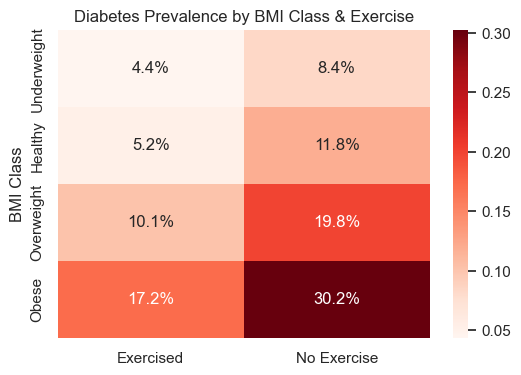

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='Reds')
plt.title('Diabetes Prevalence by BMI Class & Exercise')
plt.ylabel('BMI Class')
plt.show()

In [15]:
# Logistic regression to predict Diabetes
import statsmodels.api as sm

# Prepare design matrix
X = df_clean[['BMI','Exercise_Last30Days','Age_Group']].copy()
X['Exercise_Last30Days'] = X['Exercise_Last30Days'].replace({1:1,2:0})
X = sm.add_constant(X)

y = (df_clean['Diabetes']==1).astype(int)

model = sm.Logit(y, X).fit(disp=False)
model.summary()

C:\Users\Yassine\AppData\Local\Temp\ipykernel_18764\3221996588.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X['Exercise_Last30Days'] = X['Exercise_Last30Days'].replace({1:1,2:0})


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Diabetes   No. Observations:               306830
Model:                          Logit   Df Residuals:                   306826
Method:                           MLE   Df Model:                            3
Date:                Sat, 03 May 2025   Pseudo R-squ.:                  0.1337
Time:                        15:31:20   Log-Likelihood:            -1.0327e+05
converged:                       True   LL-Null:                   -1.1921e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -6.0020      0.037   -160.099      0.000      -6.075      -5.928
BMI                     0.0855      0.001    102.155      0.000       0.084       0.087
Exercise_Last30Days    -0.5382      0.012    -44.253      0.000      -0.562      -0.514
Age_Group               0.2246      0.002    121.622      0.000       0.221       0.228
=======================================================================================
"""

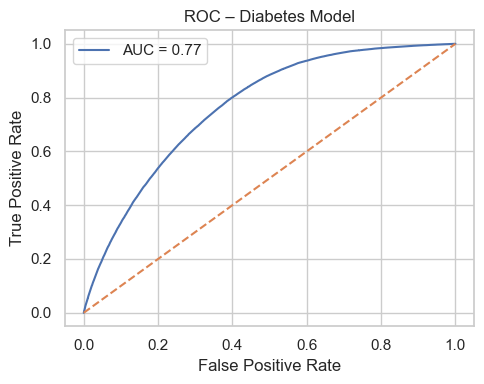

In [16]:
from sklearn.metrics import roc_curve, auc
import numpy as np

y_pred = model.predict(X)
fpr, tpr, _ = roc_curve(y, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC – Diabetes Model')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Yassine\AppData\Local\Temp\ipykernel_18764\73057805.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X_cluster['Exercise_Last30Days'] = X_cluster['Exercise_Last30Days'].replace({1:1,2:0})


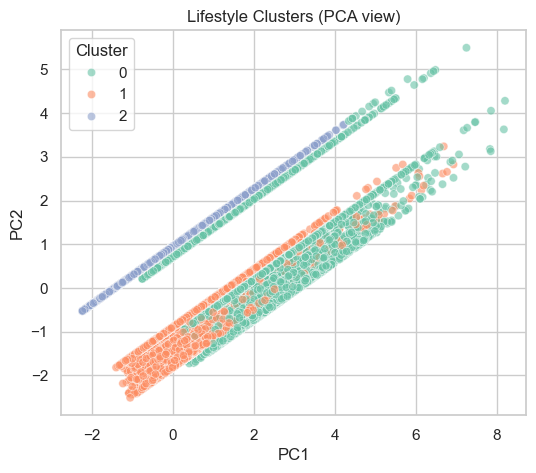

In [17]:
# Unsupervised clustering on lifestyle variables (BMI, Exercise, Physical_Health_DaysPoor)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_cluster = df_clean[['BMI','Exercise_Last30Days','Physical_Health_DaysPoor']].copy()
X_cluster['Exercise_Last30Days'] = X_cluster['Exercise_Last30Days'].replace({1:1,2:0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_clean['Cluster'] = clusters

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2', alpha=0.6)
plt.title('Lifestyle Clusters (PCA view)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [18]:
# Persist updated cleaned dataset and model coefficients for Streamlit usage
updated_path = './data/brfss2022_enriched.csv'
df_clean.to_csv(updated_path, index=False)

coeffs = model.params.to_frame(name='coef')
coeffs.to_csv('./data/diabetes_logit_coeffs.csv')
print('Saved enriched dataset and coefficients.')

Saved enriched dataset and coefficients.
